# STAP Barcode Pipeline Result Analysis

This notebook analyzes the barcode-first STAP oligo pipeline output. It compares the oligo identity inferred from the R3 barcode against the Bowtie2 aligned reference sequence, estimates how many deduplicated read1 TSS events are misaligned, and plots methylation-state counts for five oligos after removing those misaligned reads.

## 1. Packages To Install

Install these in the environment you use to launch Jupyter:

```bash
mamba install -c conda-forge -c bioconda jupyterlab pandas numpy matplotlib seaborn pysam
```

This notebook reads TSV files and BAM files, so it does not need `openpyxl`.

In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import pysam
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 120)

## Input Paths

The defaults point at the full oligo500 barcode-pipeline output. Edit `SAMPLE` or `RESULT_DIR` if you want to analyze a different run.

In [2]:
SAMPLE = "STAP_TSS_500_oligos_S2"

repo = Path.cwd()
if repo.name == "notebooks":
    repo = repo.parent

RESULT_DIR = repo / "results" / "barcode_pipeline" / SAMPLE
BAM = RESULT_DIR / f"{SAMPLE}.bowtie2.dedup.bam"
OLIGO_METADATA = RESULT_DIR / f"{SAMPLE}.oligo_metadata.tsv"
DEMUX_STATS = RESULT_DIR / f"{SAMPLE}.demux.stats.tsv"
TSS_TABLE = RESULT_DIR / f"{SAMPLE}.tss_by_oligo_meth.tsv"

for path in [RESULT_DIR, BAM, OLIGO_METADATA, DEMUX_STATS, TSS_TABLE]:
    print(path, "OK" if path.exists() else "MISSING")

/gpfs/data/zhou-lab/yczhang/methylation/STAP-seq-pipeline/results/barcode_pipeline/STAP_TSS_500_oligos_S2 OK
/gpfs/data/zhou-lab/yczhang/methylation/STAP-seq-pipeline/results/barcode_pipeline/STAP_TSS_500_oligos_S2/STAP_TSS_500_oligos_S2.bowtie2.dedup.bam OK
/gpfs/data/zhou-lab/yczhang/methylation/STAP-seq-pipeline/results/barcode_pipeline/STAP_TSS_500_oligos_S2/STAP_TSS_500_oligos_S2.oligo_metadata.tsv OK
/gpfs/data/zhou-lab/yczhang/methylation/STAP-seq-pipeline/results/barcode_pipeline/STAP_TSS_500_oligos_S2/STAP_TSS_500_oligos_S2.demux.stats.tsv OK
/gpfs/data/zhou-lab/yczhang/methylation/STAP-seq-pipeline/results/barcode_pipeline/STAP_TSS_500_oligos_S2/STAP_TSS_500_oligos_S2.tss_by_oligo_meth.tsv OK


## Load Run Summaries

`oligo_metadata.tsv` is generated in the same order used to build the 500-oligo reference FASTA. For `data_500.fa`, that means row 1 corresponds to `seq1`, row 2 to `seq2`, and so on. We use this to define the expected aligned reference for each barcode-derived `OLIGO=` tag.

In [20]:
demux_stats = pd.read_csv(DEMUX_STATS, sep="\t")
display(demux_stats)

oligo_meta = pd.read_csv(OLIGO_METADATA, sep="\t", dtype=str).fillna("")
oligo_meta["expected_chrom"] = [f"seq{i}" for i in range(1, len(oligo_meta) + 1)]
oligo_to_chrom = dict(zip(oligo_meta["oligo_id"], oligo_meta["expected_chrom"]))

print(f"Loaded {len(oligo_meta):,} oligos")
display(oligo_meta[["oligo_id", "barcode", "expected_chrom"]].head())

,metric,count
0,oligo_records_loaded,500
1,barcode_mismatches_0,35691195
2,barcode_mismatches_1,805319
3,barcode_offset_0,36496514
4,barcode_orientation_forward,26842
...,...,...
77,meth_TAG_10%,9065818
78,meth_TGA_20%,2556722
79,meth_TTT_100%,962475
80,total_triplets,43138388


Loaded 500 oligos


,oligo_id,barcode,expected_chrom
0,NativeTSS:2355:GCCCATGCAG,GCCCATGCAG,seq1
1,NativeTSS:2355:ACGCGGATTG,ACGCGGATTG,seq2
2,NativeTSS:1013:CGCACACTGG,CGCACACTGG,seq3
3,NativeTSS:1013:TAGCTCTGTG,TAGCTCTGTG,seq4
4,NativeTSS:3190:GTCCGGTTTG,GTCCGGTTTG,seq5


## 2. Misalignment From Barcode Identity Versus Aligned Sequence

A read is called **aligned_to_barcode_oligo** when the BAM reference name matches the expected `seqN` for the `OLIGO=` tag in the read name. It is called **misaligned_to_other_oligo** when the barcode says one oligo but Bowtie2 places read1 on another oligo sequence.

This section uses deduplicated primary read1 alignments, because those are the reads used for TSS quantification.

In [4]:
METH_RE = re.compile(r"(?:^|\|)METH=([^|]+)")
OLIGO_UMI_RE = re.compile(r"\|OLIGO=(.+)_([ACGTNacgtn]{22})$")

def parse_query_name(query_name):
    meth_match = METH_RE.search(query_name)
    oligo_match = OLIGO_UMI_RE.search(query_name)
    meth = meth_match.group(1) if meth_match else "UNKNOWN"
    oligo = oligo_match.group(1) if oligo_match else "UNKNOWN"
    umi = oligo_match.group(2).upper() if oligo_match else "UNKNOWN"
    return oligo, meth, umi

def read1_tss_1based(read):
    return int(read.reference_end) if read.is_reverse else int(read.reference_start) + 1

rows = []
with pysam.AlignmentFile(BAM, "rb") as bam:
    for read in bam.fetch(until_eof=True):
        if not read.is_read1:
            continue
        if read.is_unmapped or read.is_secondary or read.is_supplementary:
            continue
        if read.is_qcfail or read.is_duplicate:
            continue
        oligo, meth, umi = parse_query_name(read.query_name)
        aligned_chrom = bam.get_reference_name(read.reference_id)
        expected_chrom = oligo_to_chrom.get(oligo, "UNKNOWN")
        if expected_chrom == "UNKNOWN":
            status = "unknown_oligo_tag"
        elif aligned_chrom == expected_chrom:
            status = "aligned_to_barcode_oligo"
        else:
            status = "misaligned_to_other_oligo"
        rows.append({
            "read_name": read.query_name,
            "oligo_id": oligo,
            "meth_state": meth,
            "umi": umi,
            "expected_chrom": expected_chrom,
            "aligned_chrom": aligned_chrom,
            "tss_position": read1_tss_1based(read),
            "mapq": read.mapping_quality,
            "is_reverse": read.is_reverse,
            "status": status,
        })

read1_df = pd.DataFrame(rows)
print(f"Deduplicated primary mapped read1 records: {len(read1_df):,}")
display(read1_df.head())

Deduplicated primary mapped read1 records: 236,109


,read_name,oligo_id,meth_state,umi,expected_chrom,aligned_chrom,tss_position,mapq,is_reverse,status
0,VH01570:206:AAJ2NL3M5:1:1510:40499:49390|METH=20%|OLIGO=NativeTSS:2355:GCCCATGCAG_CTGCGCGGTTTAATAGAAAATA,NativeTSS:2355:GCCCATGCAG,20%,CTGCGCGGTTTAATAGAAAATA,seq1,seq1,140,42,False,aligned_to_barcode_oligo
1,VH01570:206:AAJ2NL3M5:1:1608:70569:8573|METH=10%|OLIGO=NativeTSS:2355:GCCCATGCAG_ACAAAACAAATAGAGATGTGTG,NativeTSS:2355:GCCCATGCAG,10%,ACAAAACAAATAGAGATGTGTG,seq1,seq1,143,34,False,aligned_to_barcode_oligo
2,VH01570:206:AAJ2NL3M5:1:2610:29346:47137|METH=10%|OLIGO=NativeTSS:2355:GCCCATGCAG_TGGTACACGTGAGGGAGAAAAA,NativeTSS:2355:GCCCATGCAG,10%,TGGTACACGTGAGGGAGAAAAA,seq1,seq1,146,34,False,aligned_to_barcode_oligo
3,VH01570:206:AAJ2NL3M5:1:1401:29025:54577|METH=10%|OLIGO=NativeTSS:2355:GCCCATGCAG_ACGCGCACAGATGGGTGAGGTA,NativeTSS:2355:GCCCATGCAG,10%,ACGCGCACAGATGGGTGAGGTA,seq1,seq1,148,42,False,aligned_to_barcode_oligo
4,VH01570:206:AAJ2NL3M5:1:1209:69262:14006|METH=10%|OLIGO=NativeTSS:2355:GCCCATGCAG_GCGATCTCATAAGGGAAAAGGG,NativeTSS:2355:GCCCATGCAG,10%,GCGATCTCATAAGGGAAAAGGG,seq1,seq1,148,34,False,aligned_to_barcode_oligo


In [5]:
status_summary = (
    read1_df.groupby("status")
    .size()
    .rename("reads")
    .reset_index()
    .assign(frac=lambda d: d["reads"] / d["reads"].sum())
    .sort_values("reads", ascending=False)
)
display(status_summary)

misaligned_df = read1_df.query("status == 'misaligned_to_other_oligo'").copy()
print(f"Misaligned read1 records: {len(misaligned_df):,}")
print(f"Misaligned fraction: {len(misaligned_df) / max(len(read1_df), 1):.2%}")

,status,reads,frac
0,aligned_to_barcode_oligo,235297,0.996561
1,misaligned_to_other_oligo,812,0.003439


Misaligned read1 records: 812
Misaligned fraction: 0.34%


In [6]:
mis_by_meth = (
    read1_df.assign(is_misaligned=read1_df["status"].eq("misaligned_to_other_oligo"))
    .groupby("meth_state")
    .agg(total_reads=("read_name", "size"), misaligned_reads=("is_misaligned", "sum"))
    .assign(misaligned_frac=lambda d: d["misaligned_reads"] / d["total_reads"])
    .sort_index()
)
display(mis_by_meth)

top_misalignment_pairs = (
    misaligned_df.groupby(["oligo_id", "expected_chrom", "aligned_chrom"])
    .size()
    .rename("reads")
    .reset_index()
    .sort_values("reads", ascending=False)
    .head(20)
)
display(top_misalignment_pairs)

,total_reads,misaligned_reads,misaligned_frac
meth_state,,,
0%,46758,125,0.002673
0.1%,46308,161,0.003477
1%,49576,170,0.003429
10%,50659,151,0.002981
100%,8067,27,0.003347
20%,18549,64,0.003450
40%,8373,63,0.007524
60%,7819,51,0.006523


,oligo_id,expected_chrom,aligned_chrom,reads
22,NativeTSS:1874:GTGTCTCTTT,seq186,seq185,76
199,SyntheticTSS:2625038:ATGGTGGACT,seq300,seq334,56
23,NativeTSS:1914:ACCCTCACAA,seq134,seq133,30
67,NativeTSS:3055:GATGCCCGTA,seq146,seq145,24
132,NativeTSS:596:CTGCACCATC,seq138,seq137,21
141,NativeTSS:6687:CTCAGTGGTA,seq26,seq182,18
25,NativeTSS:1914:CTCAATCCTC,seq133,seq134,16
127,NativeTSS:559:GCCCTCTACA,seq44,seq43,16
50,NativeTSS:259:CATCGGGCGT,seq178,seq177,15
51,NativeTSS:259:CATCGGGCGT,seq178,seq21,14


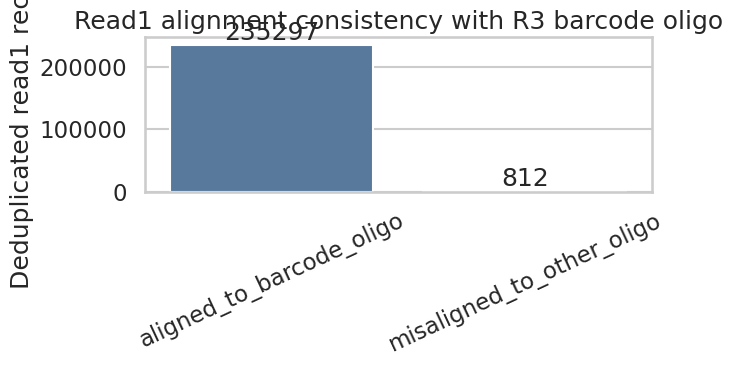

In [11]:
fig, ax = plt.subplots(figsize=(7, 4))
plot_status = status_summary.copy()
sns.barplot(data=plot_status, x="status", y="reads", ax=ax, color="#4C78A8")
ax.set_xlabel("")
ax.set_ylabel("Deduplicated read1 records")
ax.set_title("Read1 alignment consistency with R3 barcode oligo")
ax.tick_params(axis="x", rotation=25)
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")
plt.tight_layout()

## 3. Five-Oligo Methylation Counts After Removing Misaligned Reads

The next cells discard reads where the aligned reference sequence disagrees with the barcode-derived oligo. By default, the notebook selects the five oligos with the most remaining read1 records. You can replace `selected_oligos` with any five `oligo_id` values.

In [7]:
aligned_only = read1_df.query("status == 'aligned_to_barcode_oligo'").copy()

# Set this manually if desired, e.g.:
# selected_oligos = ["NativeTSS:2355:GCCCATGCAG", "NativeTSS:2355:ACGCGGATTG", ...]
selected_oligos = (
    aligned_only.groupby("oligo_id")
    .size()
    .sort_values(ascending=False)
    .head(5)
    .index
    .tolist()
)

print("Selected oligos:")
for oligo in selected_oligos:
    print("  ", oligo)

meth_order = ["0%", "0.1%", "1%", "10%", "20%", "40%", "60%", "100%"]
selected_df = aligned_only[aligned_only["oligo_id"].isin(selected_oligos)].copy()

counts = (
    selected_df.groupby(["oligo_id", "meth_state"])
    .size()
    .rename("Count")
    .reset_index()
)
full_index = pd.MultiIndex.from_product([selected_oligos, meth_order], names=["oligo_id", "meth_state"])
counts = (
    counts.set_index(["oligo_id", "meth_state"])
    .reindex(full_index, fill_value=0)
    .reset_index()
)
display(counts.head(20))

Selected oligos:
   NativeTSS:2416:CCTTGACTGG
   SyntheticTSS:1010643:CGGGCACTAA
   NativeTSS:6749:CCATGCACAC
   promoter_design:tss68_real:CTCCTAAAGG
   SyntheticTSS:2992677:CCTTTGGTTG


,oligo_id,meth_state,Count
0,NativeTSS:2416:CCTTGACTGG,0%,1732
1,NativeTSS:2416:CCTTGACTGG,0.1%,1686
2,NativeTSS:2416:CCTTGACTGG,1%,1729
3,NativeTSS:2416:CCTTGACTGG,10%,1688
4,NativeTSS:2416:CCTTGACTGG,20%,648
5,NativeTSS:2416:CCTTGACTGG,40%,319
6,NativeTSS:2416:CCTTGACTGG,60%,257
7,NativeTSS:2416:CCTTGACTGG,100%,270
8,SyntheticTSS:1010643:CGGGCACTAA,0%,1687
9,SyntheticTSS:1010643:CGGGCACTAA,0.1%,1605


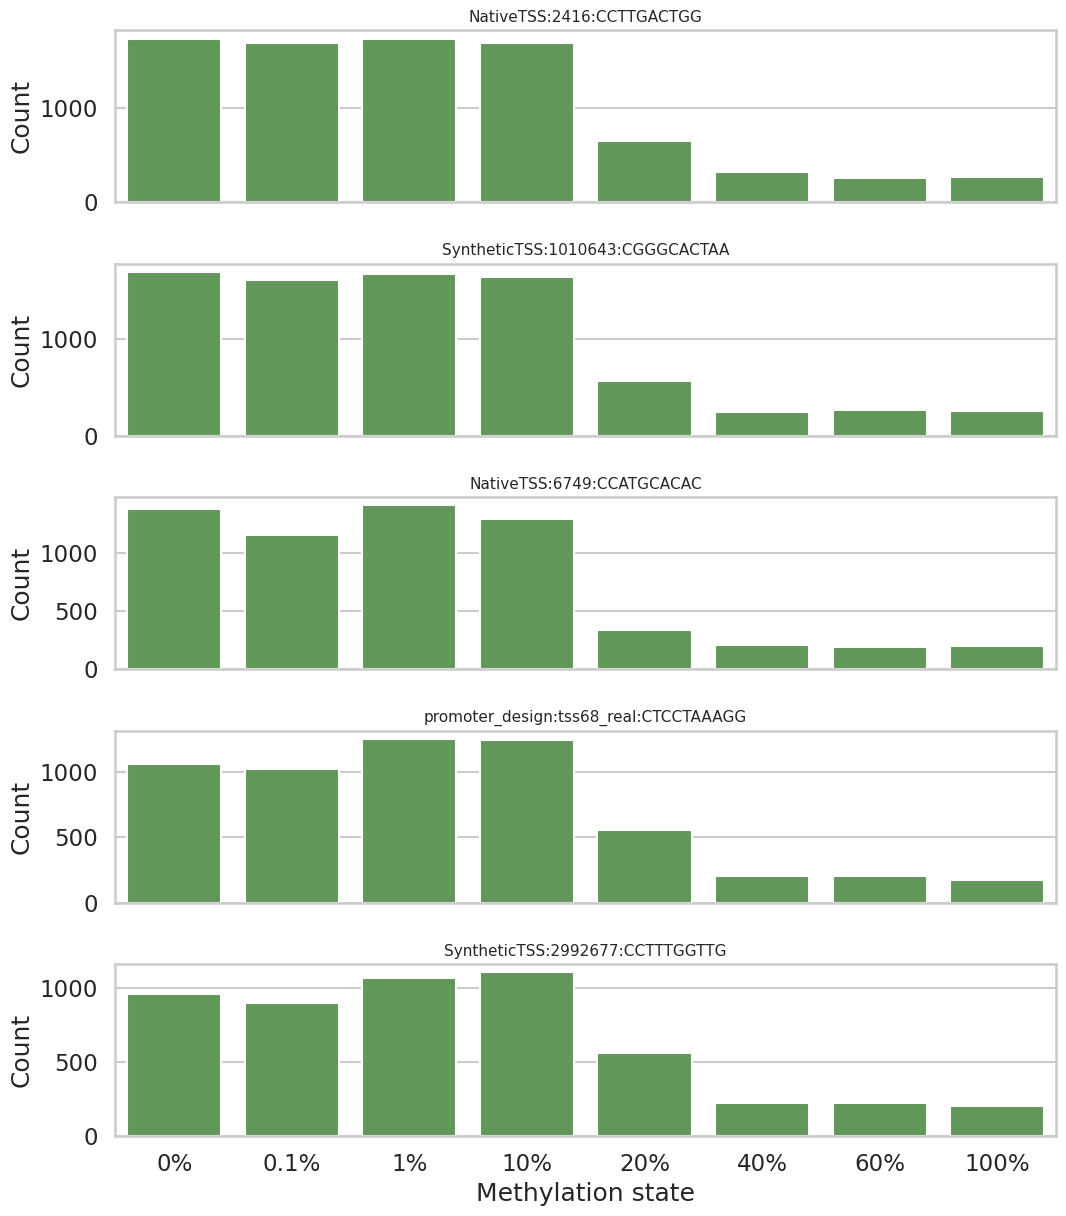

In [13]:
fig, axes = plt.subplots(len(selected_oligos), 1, figsize=(11, 2.5 * len(selected_oligos)), sharex=True)
if len(selected_oligos) == 1:
    axes = [axes]

for ax, oligo in zip(axes, selected_oligos):
    sub = counts[counts["oligo_id"] == oligo]
    sns.barplot(data=sub, x="meth_state", y="Count", order=meth_order, ax=ax, color="#59A14F")
    ax.set_title(oligo, fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("Count")
plt.xlabel("Methylation state")
plt.tight_layout()

,meth_state,Count
0,0%,6808
1,0.1%,6357
2,1%,7118
3,10%,6962
5,20%,2664
6,40%,1191
7,60%,1134
4,100%,1103


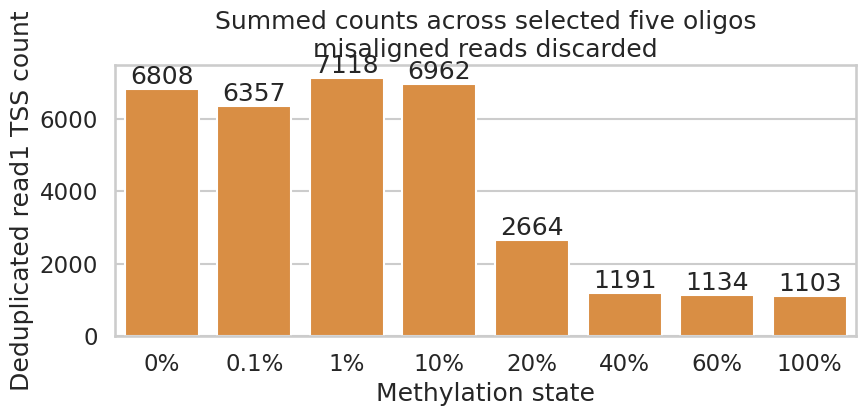

In [14]:
summed_counts = counts.groupby("meth_state", as_index=False)["Count"].sum()
summed_counts["meth_state"] = pd.Categorical(summed_counts["meth_state"], categories=meth_order, ordered=True)
summed_counts = summed_counts.sort_values("meth_state")

fig, ax = plt.subplots(figsize=(9, 4.5))
sns.barplot(data=summed_counts, x="meth_state", y="Count", order=meth_order, ax=ax, color="#F28E2B")
ax.set_title("Summed counts across selected five oligos\nmisaligned reads discarded")
ax.set_xlabel("Methylation state")
ax.set_ylabel("Deduplicated read1 TSS count")
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f")
plt.tight_layout()
display(summed_counts)

## Optional: Save Aligned-Only TSS Counts

This writes a filtered table with the same main columns as the pipeline final output, but after removing barcode/alignment disagreements.

In [8]:
SAVE_FILTERED_COUNTS = True

filtered_tss_counts = (
    aligned_only.groupby(["oligo_id", "meth_state", "aligned_chrom", "tss_position"])
    .size()
    .rename("Count")
    .reset_index()
    .rename(columns={
        "oligo_id": "Oligo_ID",
        "meth_state": "Meth_State",
        "aligned_chrom": "Chromosome",
        "tss_position": "TSS_Position",
    })
)

display(filtered_tss_counts.head())

if SAVE_FILTERED_COUNTS:
    out_path = RESULT_DIR / f"{SAMPLE}.tss_by_oligo_meth.aligned_only.tsv"
    filtered_tss_counts.to_csv(out_path, sep="\t", index=False)
    print(out_path)

,Oligo_ID,Meth_State,Chromosome,TSS_Position,Count
0,CRISPer-promoters:10_TXNRD2_chr22_19941817_-:CAGGGAATCG,0%,seq413,172,2
1,CRISPer-promoters:10_TXNRD2_chr22_19941817_-:CAGGGAATCG,0%,seq413,207,1
2,CRISPer-promoters:10_TXNRD2_chr22_19941817_-:CAGGGAATCG,0%,seq413,214,1
3,CRISPer-promoters:10_TXNRD2_chr22_19941817_-:CAGGGAATCG,0.1%,seq413,115,1
4,CRISPer-promoters:10_TXNRD2_chr22_19941817_-:CAGGGAATCG,0.1%,seq413,117,2


/gpfs/data/zhou-lab/yczhang/methylation/STAP-seq-pipeline/results/barcode_pipeline/STAP_TSS_500_oligos_S2/STAP_TSS_500_oligos_S2.tss_by_oligo_meth.aligned_only.tsv


In [3]:
filtered_tss_counts = pd.read_csv(RESULT_DIR / f"{SAMPLE}.tss_by_oligo_meth.aligned_only.tsv", sep='\t')

In [5]:
filtered_tss_counts_agg = filtered_tss_counts.groupby(["Oligo_ID", "Meth_State"], as_index=False)['Count'].agg('sum')
filtered_tss_counts_agg.head()

,Oligo_ID,Meth_State,Count
0,CRISPer-promoters:10_TXNRD2_chr22_19941817_-:CAGGGAATCG,0%,4
1,CRISPer-promoters:10_TXNRD2_chr22_19941817_-:CAGGGAATCG,0.1%,8
2,CRISPer-promoters:10_TXNRD2_chr22_19941817_-:CAGGGAATCG,1%,4
3,CRISPer-promoters:10_TXNRD2_chr22_19941817_-:CAGGGAATCG,10%,7
4,CRISPer-promoters:10_TXNRD2_chr22_19941817_-:CAGGGAATCG,100%,1


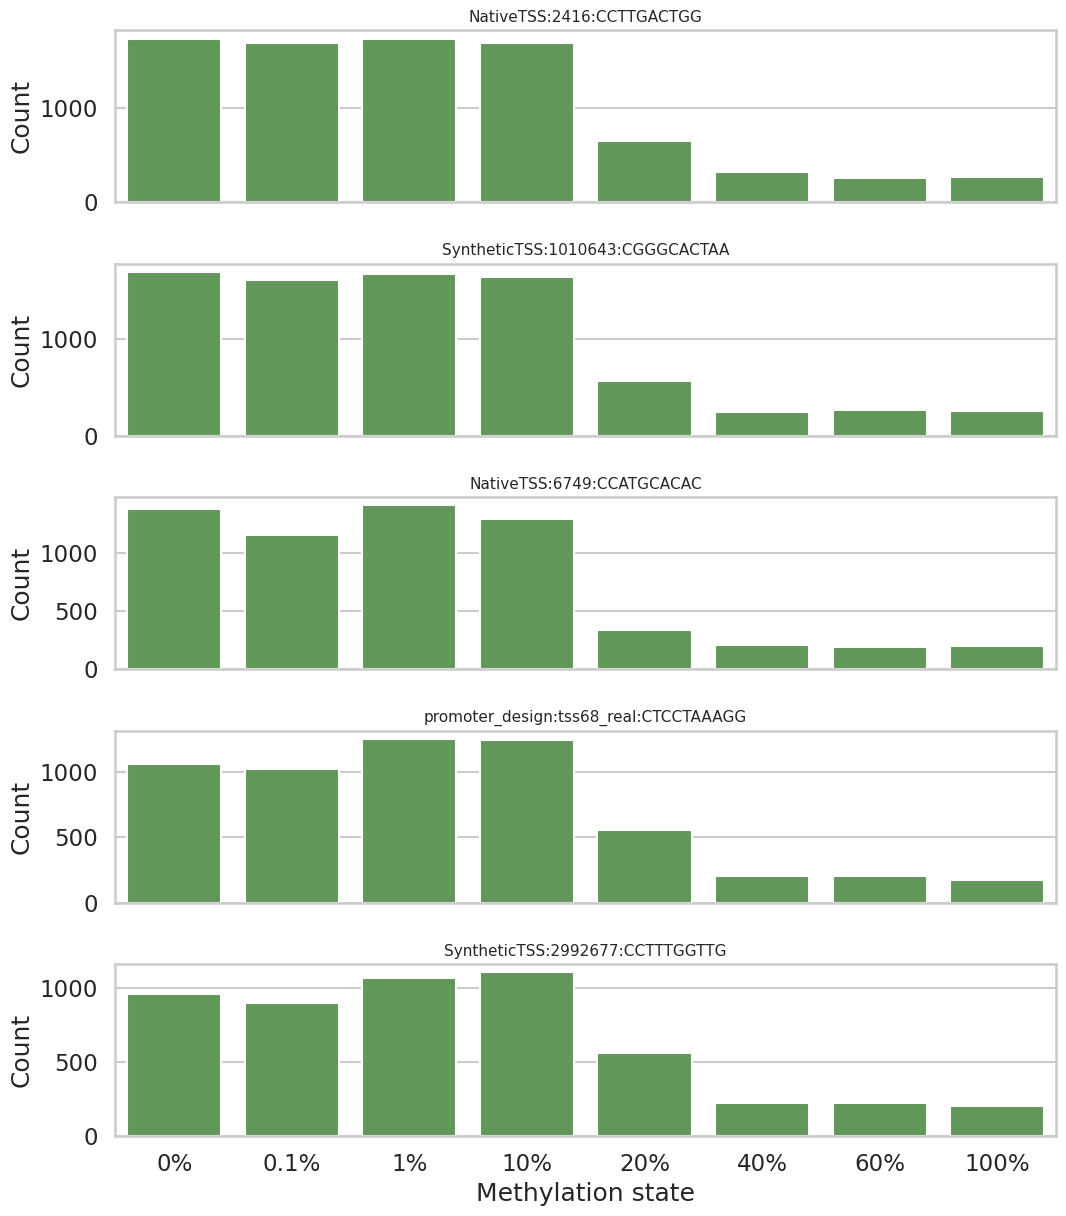

In [10]:
fig, axes = plt.subplots(len(selected_oligos), 1, figsize=(11, 2.5 * len(selected_oligos)), sharex=True)
if len(selected_oligos) == 1:
    axes = [axes]

for ax, oligo in zip(axes, selected_oligos):
    sub = filtered_tss_counts_agg[filtered_tss_counts_agg["Oligo_ID"] == oligo]
    sns.barplot(data=sub, x="Meth_State", y="Count", order=meth_order, ax=ax, color="#59A14F")
    ax.set_title(oligo, fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("Count")
plt.xlabel("Methylation state")
plt.tight_layout()

# Statistical test in motif deletion

In [ ]:
filtered_tss_counts_agg.loc[filtered_tss_counts_agg['Oligo_ID'].str.contains("NativeTSS:2355")]

,Oligo_ID,Meth_State,Count
447,NativeTSS:2355:ACGCGGATTG,0%,5
448,NativeTSS:2355:ACGCGGATTG,0.1%,4
449,NativeTSS:2355:ACGCGGATTG,1%,8
450,NativeTSS:2355:ACGCGGATTG,10%,2
451,NativeTSS:2355:ACGCGGATTG,60%,2
452,NativeTSS:2355:GCCCATGCAG,0%,149
453,NativeTSS:2355:GCCCATGCAG,0.1%,132
454,NativeTSS:2355:GCCCATGCAG,1%,143
455,NativeTSS:2355:GCCCATGCAG,10%,166
456,NativeTSS:2355:GCCCATGCAG,100%,14


In [16]:
filtered_tss_counts_agg.loc[filtered_tss_counts_agg['Oligo_ID'].str.contains("NativeTSS:1013")]

,Oligo_ID,Meth_State,Count
229,NativeTSS:1013:CGCACACTGG,0%,783
230,NativeTSS:1013:CGCACACTGG,0.1%,751
231,NativeTSS:1013:CGCACACTGG,1%,782
232,NativeTSS:1013:CGCACACTGG,10%,737
233,NativeTSS:1013:CGCACACTGG,100%,120
234,NativeTSS:1013:CGCACACTGG,20%,240
235,NativeTSS:1013:CGCACACTGG,40%,72
236,NativeTSS:1013:CGCACACTGG,60%,114
237,NativeTSS:1013:TAGCTCTGTG,0%,57
238,NativeTSS:1013:TAGCTCTGTG,0.1%,47


In [26]:
native_tss_counts = filtered_tss_counts_agg.loc[filtered_tss_counts_agg['Oligo_ID'].str.contains("NativeTSS")]
native_tss_counts = pd.merge(native_tss_counts, oligo_meta[['oligo_id','del motif']].rename(columns={'oligo_id':'Oligo_ID'}), how='left')
native_tss_counts.head()

,Oligo_ID,Meth_State,Count,del motif
0,NativeTSS:1013:CGCACACTGG,0%,783,ZNF143+
1,NativeTSS:1013:CGCACACTGG,0.1%,751,ZNF143+
2,NativeTSS:1013:CGCACACTGG,1%,782,ZNF143+
3,NativeTSS:1013:CGCACACTGG,10%,737,ZNF143+
4,NativeTSS:1013:CGCACACTGG,100%,120,ZNF143+


In [ ]:
native_tss_counts_znf143 = native_tss_counts.loc[native_tss_counts['del motif'].str.contains("ZNF143+")]
native_tss_counts_znf143.head()

,Oligo_ID,Meth_State,Count,del motif
0,NativeTSS:1013:CGCACACTGG,0%,783,ZNF143+
1,NativeTSS:1013:CGCACACTGG,0.1%,751,ZNF143+
2,NativeTSS:1013:CGCACACTGG,1%,782,ZNF143+
3,NativeTSS:1013:CGCACACTGG,10%,737,ZNF143+
4,NativeTSS:1013:CGCACACTGG,100%,120,ZNF143+


In [30]:
native_tss_counts_znf143.to_csv("tss_znf143.tsv", sep='\t', index=False)

In [59]:
import statsmodels.formula.api as smf

df = native_tss_counts.loc[native_tss_counts['del motif'].str.contains("NRF\+")]

# 2. Data Preprocessing
print("--- Preprocessing Data ---")

# Convert Meth_State from strings like '10%' to floats like 0.10
df['Meth_Float'] = df['Meth_State'].str.rstrip('%').astype(float) / 100.0

# Extract the Promoter ID (e.g., '1013' from 'NativeTSS:1013:CGCACACTGG')
df['Promoter'] = df['Oligo_ID'].apply(lambda x: x.split(':')[1])

# Create a clean binary column for Motif Status (WT vs Del)
df['Motif_Status'] = df['del motif'].apply(lambda x: 'Deleted' if 'del' in x else 'WT')

print(df[['Promoter', 'Meth_Float', 'Motif_Status', 'Count']].head())
print("\n")

# 3. Fit the Negative Binomial Model
print("--- Fitting Negative Binomial GLM ---")

# Formula: Count depends on Methylation, Motif Status, their interaction, and the Promoter background
# The '*' operator automatically includes main effects and the interaction term
formula = 'Count ~ Meth_Float * C(Motif_Status) + C(Promoter)'

# Fit the model
model = smf.negativebinomial(formula, data=df).fit(disp=0)

# 4. View Results
print("\n--- Model Summary ---")
print(model.summary())

--- Preprocessing Data ---
   Promoter  Meth_Float Motif_Status  Count
64     1613       0.001      Deleted      3
65     1613       0.010      Deleted      5
66     1613       0.100      Deleted      4
67     1613       0.200      Deleted      2
68     1613       0.600      Deleted      1


--- Fitting Negative Binomial GLM ---

--- Model Summary ---
                     NegativeBinomial Regression Results                      
Dep. Variable:                  Count   No. Observations:                   75
Model:               NegativeBinomial   Df Residuals:                       67
Method:                           MLE   Df Model:                            7
Date:                Tue, 02 Jun 2026   Pseudo R-squ.:                  0.2048
Time:                        16:08:07   Log-Likelihood:                -331.67
converged:                       True   LL-Null:                       -417.08
Covariance Type:            nonrobust   LLR p-value:                 1.690e-33
              

In [72]:
%%capture my_output

import re
import statsmodels.formula.api as smf

motif_list = ['ZNF143+', 'ZNF143-', 'SP+', 'SP-', 'ETS+', 'ETS-', 'CREB+', 'CREB-', 'NFY+', 'NFY-', 'NRF+', 'NRF-', 'U1 snRNP+', 'YY1+', 'TATA+', 'Long Inr +']
for motif in motif_list:
    df = native_tss_counts.loc[native_tss_counts['del motif'].str.contains(re.escape(motif))]
    # 2. Data Preprocessing
    print(f"--- Preprocessing {motif} ---")

    # Convert Meth_State from strings like '10%' to floats like 0.10
    df['Meth_Float'] = df['Meth_State'].str.rstrip('%').astype(float) / 100.0

    # Extract the Promoter ID (e.g., '1013' from 'NativeTSS:1013:CGCACACTGG')
    df['Promoter'] = df['Oligo_ID'].apply(lambda x: x.split(':')[1])

    # Create a clean binary column for Motif Status (WT vs Del)
    df['Motif_Status'] = df['del motif'].apply(lambda x: 'Deleted' if 'del' in x else 'WT')

    # Formula: Count depends on Methylation, Motif Status, their interaction, and the Promoter background
    # The '*' operator automatically includes main effects and the interaction term
    formula = 'Count ~ Meth_Float * C(Motif_Status) + C(Promoter)'

    # Fit the model
    model = smf.negativebinomial(formula, data=df).fit(disp=0)

    # 4. View Results
    print("\n--- Model Summary ---")
    print(model.summary())

In [75]:
with open('./intermediate_data/native_tss_del_motif_glm.txt', 'w') as f:
    f.write(my_output.stdout)